<a href="https://colab.research.google.com/github/BintangPray/Kelompok-5-P2/blob/main/FINAL_LSTM%20HARGA%20CABAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
import seaborn as sns

# Impor Data

In [ ]:
import os
import random
seed_value = 1016
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [ ]:
data = pd.read_excel("/content/Penanganan.xlsx")
data = data.loc[:, ['Tanggal','Wisatawan']]
data = data.iloc[:312].reset_index(drop=True)
print(data)
print(data.shape)

       Tanggal  Wisatawan
0   2000-01-01     356090
1   2000-02-01     397548
2   2000-03-01     413502
3   2000-04-01     408239
4   2000-05-01     370474
..         ...        ...
307 2025-08-01    1505220
308 2025-09-01    1394910
309 2025-10-01    1348993
310 2025-11-01    1199007
311 2025-12-01    1405860

[312 rows x 2 columns]
(312, 2)


Text(0, 0.5, 'Jumlah Wisatawan')

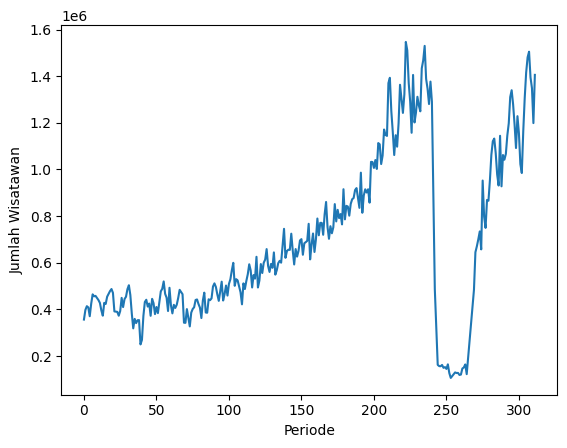

In [ ]:
plt.plot(data['Wisatawan'])
plt.xlabel('Periode')
plt.ylabel('Jumlah Wisatawan')

### Normalisasi Data

Proses normalisasi data dilakukan menggunakan metode _min-max normalization_ hingga menghasilkan data yang bersakala [0,1].

Text(0, 0.5, 'Jumlah Wisatawan Normalisasi')

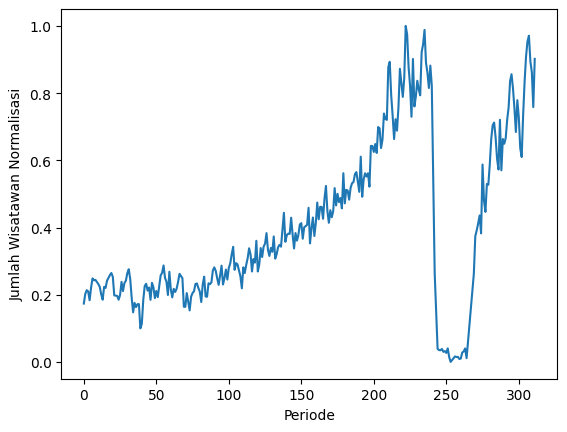

In [ ]:
# Step 1: Normalize the data using Min-Max scaling
scaler = MinMaxScaler()
data['Wisatawan_normalized'] = scaler.fit_transform(data['Wisatawan'].values.reshape(-1, 1))
plt.plot(data['Wisatawan_normalized'])
plt.xlabel('Periode')
plt.ylabel('Jumlah Wisatawan Normalisasi')

# Hyperparameter Tuning

_Hyperparameter tuning_ dilakukan untuk menentukan _hyperparameter_ terbaik melalui langkah validasi berupa _time series k-fold cross validation_. Banyaknya _fold_ yang digunakan dalam langkah validasi adalah sebanyak 5.

### Skenario 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step


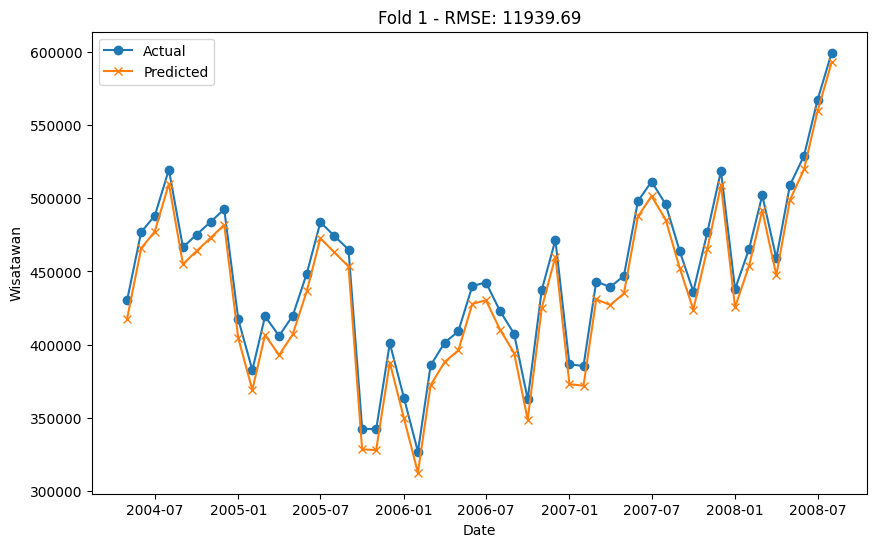

Fold 1 - RMSE: 11939.69


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step


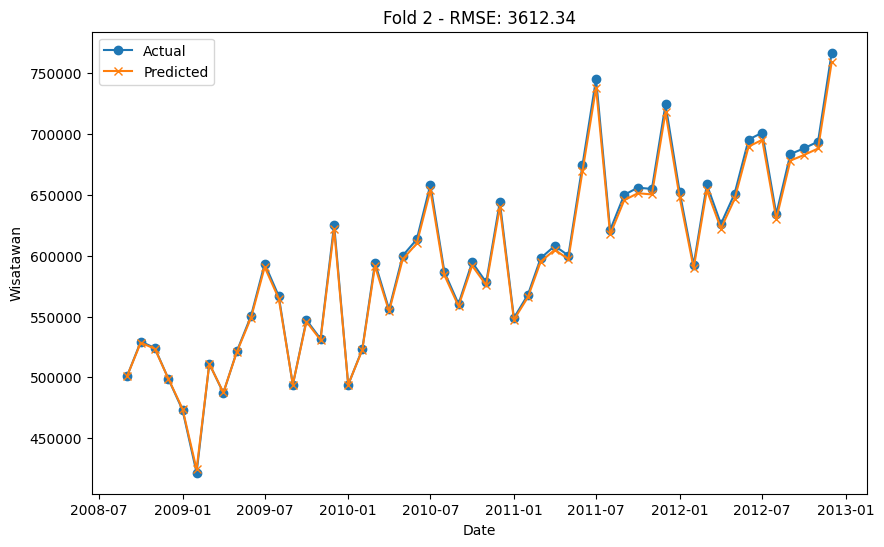

Fold 2 - RMSE: 3612.34


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step


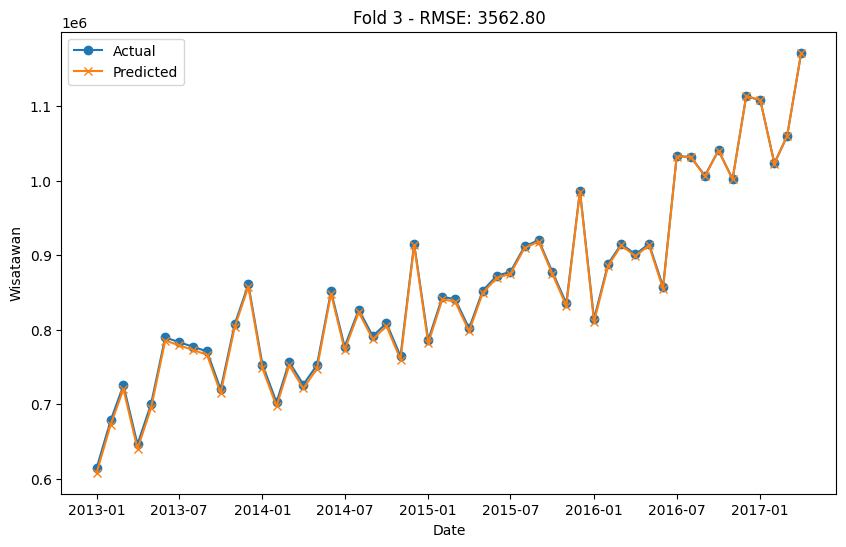

Fold 3 - RMSE: 3562.80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step


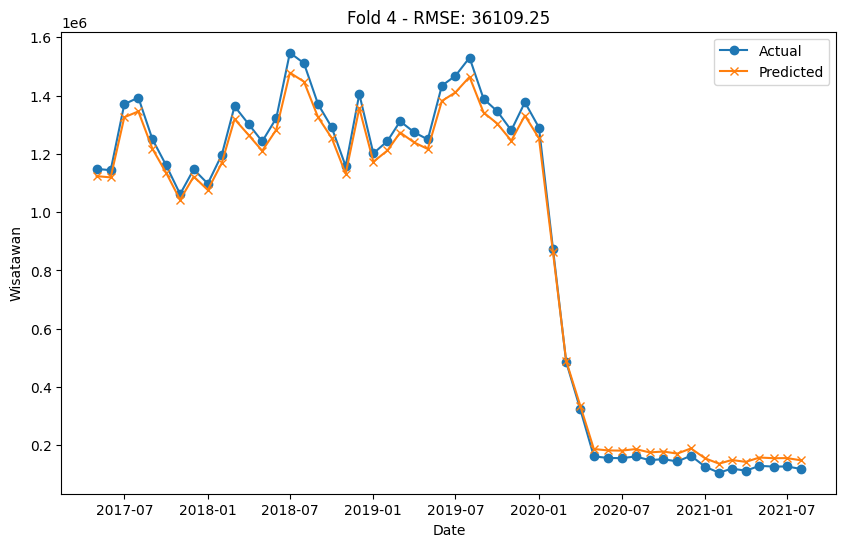

Fold 4 - RMSE: 36109.25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step


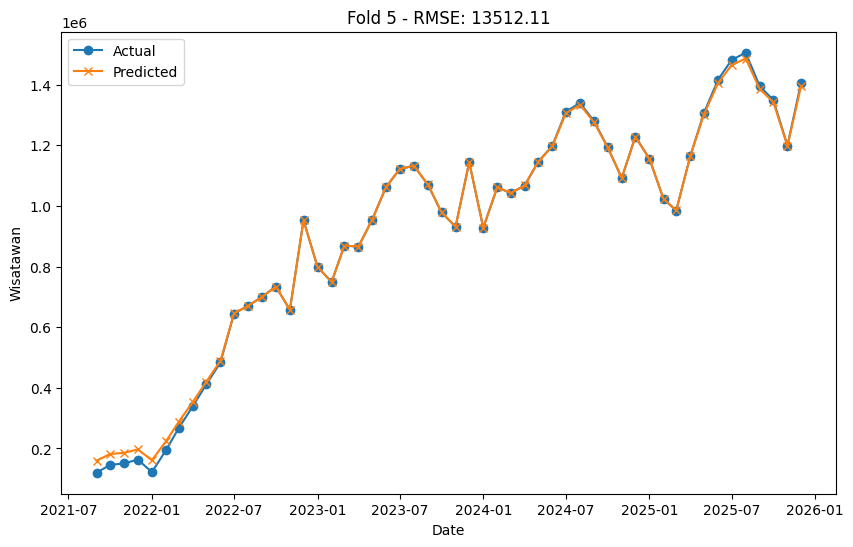

Fold 5 - RMSE: 13512.11

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.01, Batch Size=16
Rata-rata RMSE dari 5-Fold: 13747.24


In [ ]:
#EPOCH: 100, LEARNING RATE: 0,01 dan BATCH SIZE: 16

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.01
batch_size = 16
epochs = 100
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 2

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step


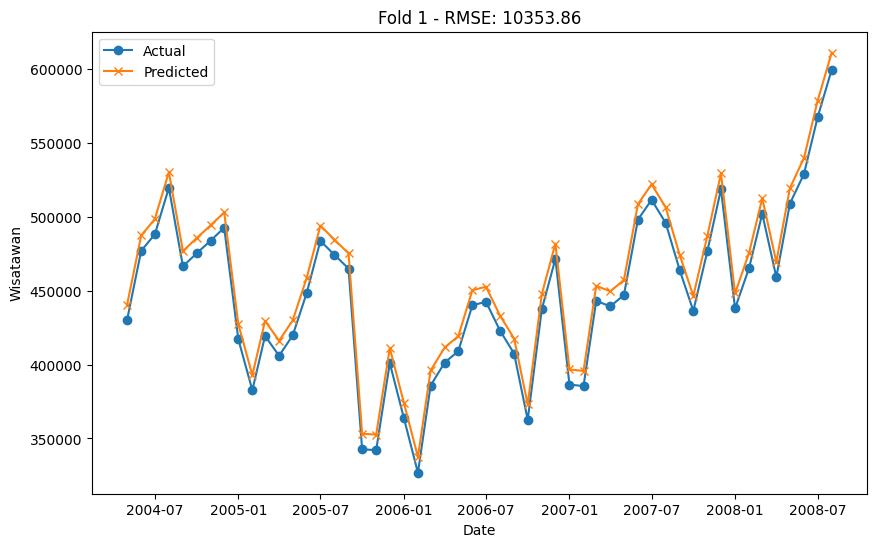

Fold 1 - RMSE: 10353.86


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step


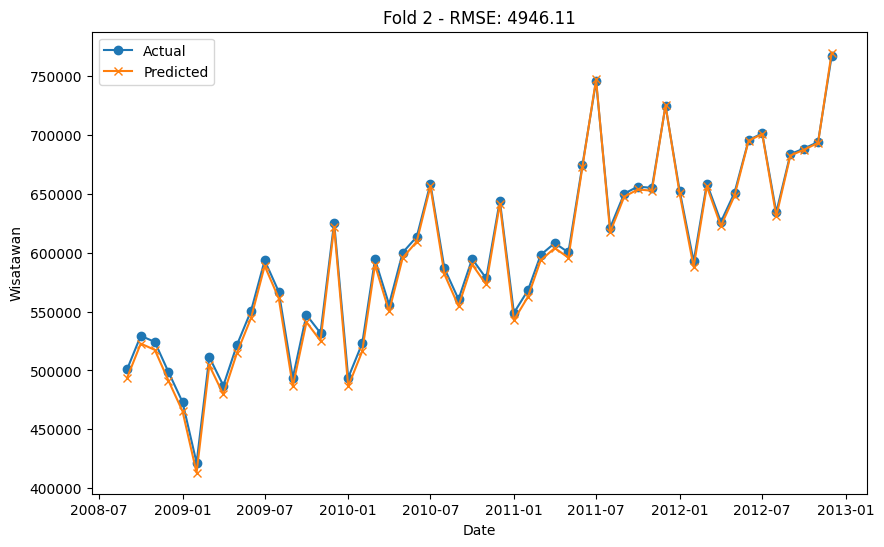

Fold 2 - RMSE: 4946.11


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step


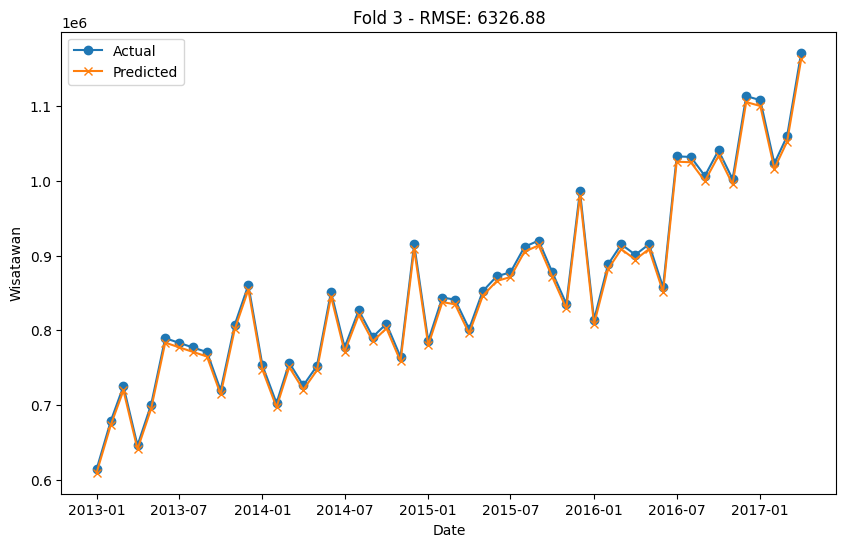

Fold 3 - RMSE: 6326.88


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step


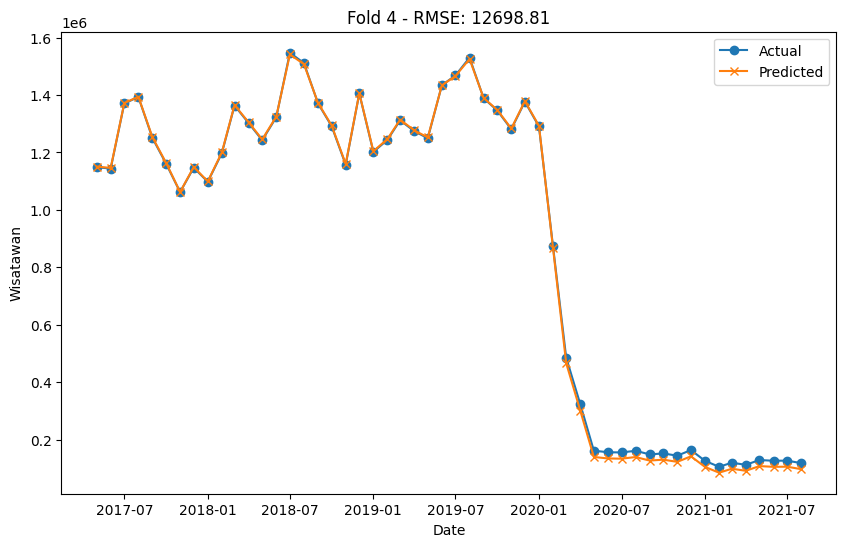

Fold 4 - RMSE: 12698.81


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step


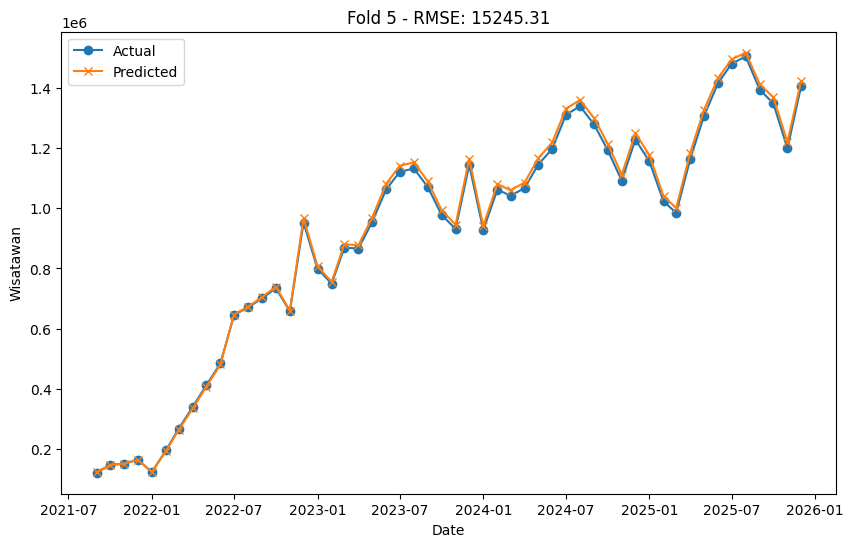

Fold 5 - RMSE: 15245.31

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.01, Batch Size=32
Rata-rata RMSE dari 5-Fold: 9914.19


In [ ]:
#EPOCH: 100, LEARNING RATE: 0,01 dan BATCH SIZE: 32

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.01
batch_size = 32
epochs = 100
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 3

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step


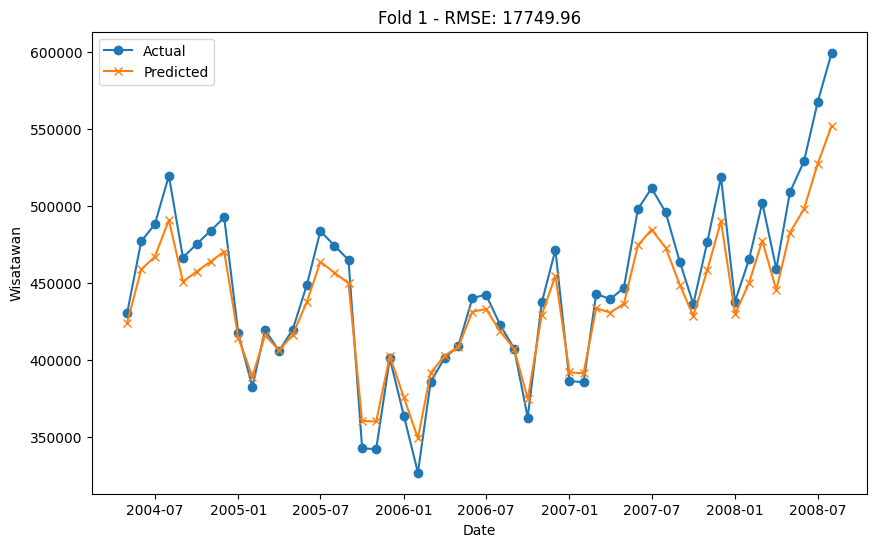

Fold 1 - RMSE: 17749.96


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step


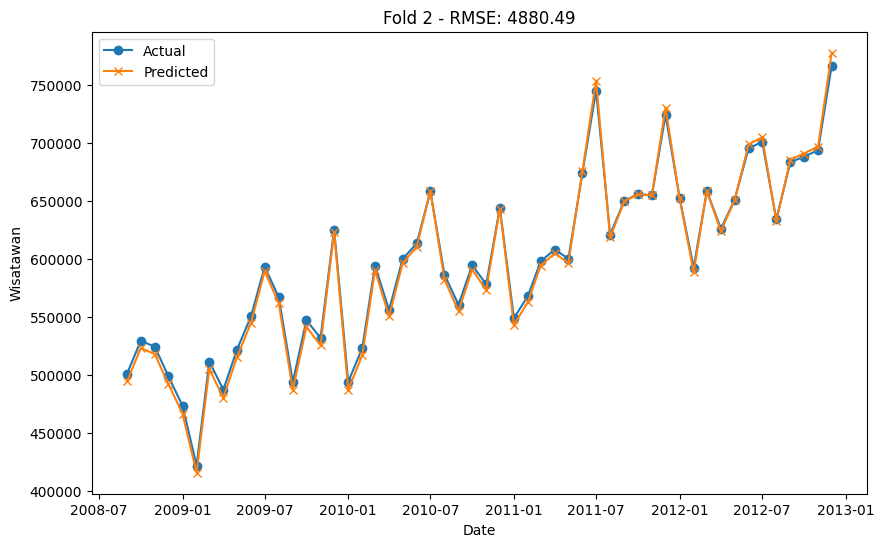

Fold 2 - RMSE: 4880.49


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step


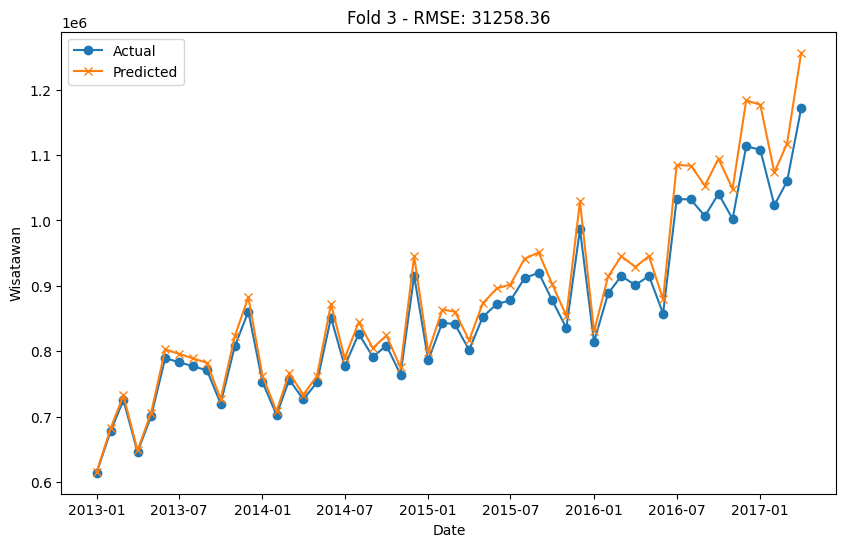

Fold 3 - RMSE: 31258.36


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step


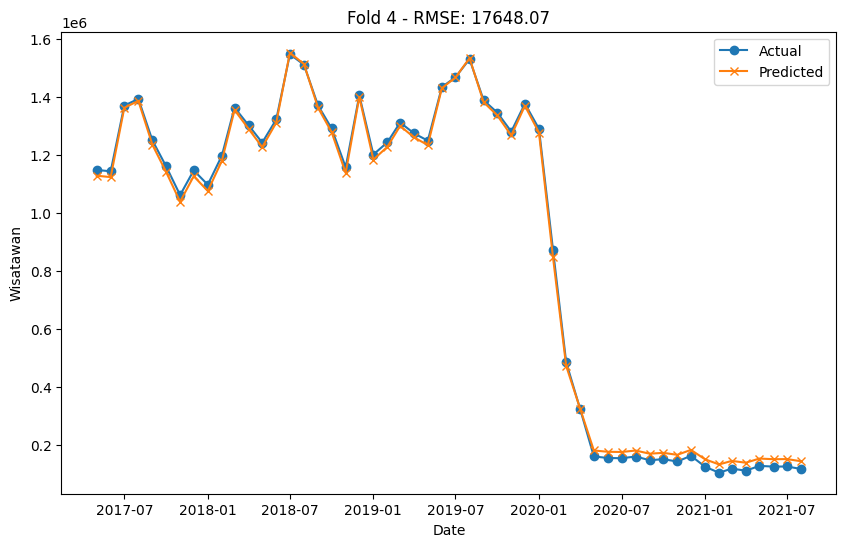

Fold 4 - RMSE: 17648.07


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 433ms/step


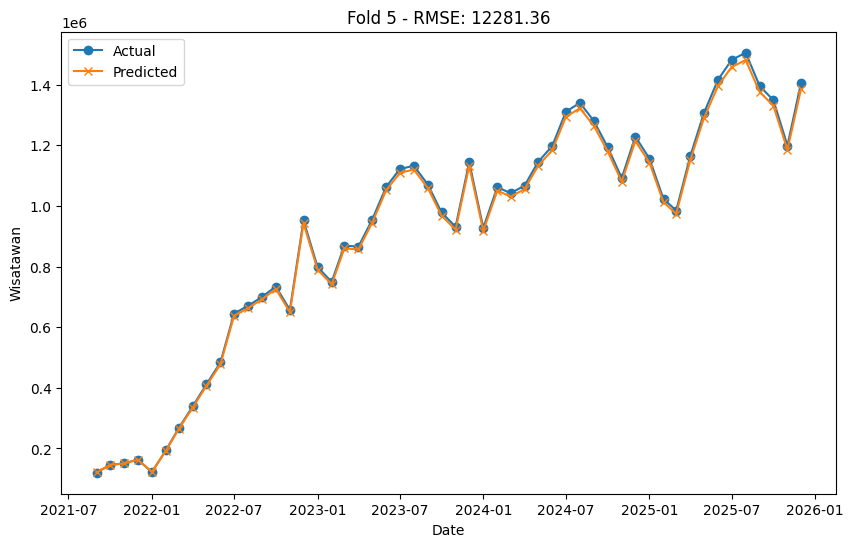

Fold 5 - RMSE: 12281.36

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.001, Batch Size=16
Rata-rata RMSE dari 5-Fold: 16763.65


In [ ]:
#EPOCH: 100, LEARNING RATE: 0,001 dan BATCH SIZE: 16

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.001
batch_size = 16
epochs = 100
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 4

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step


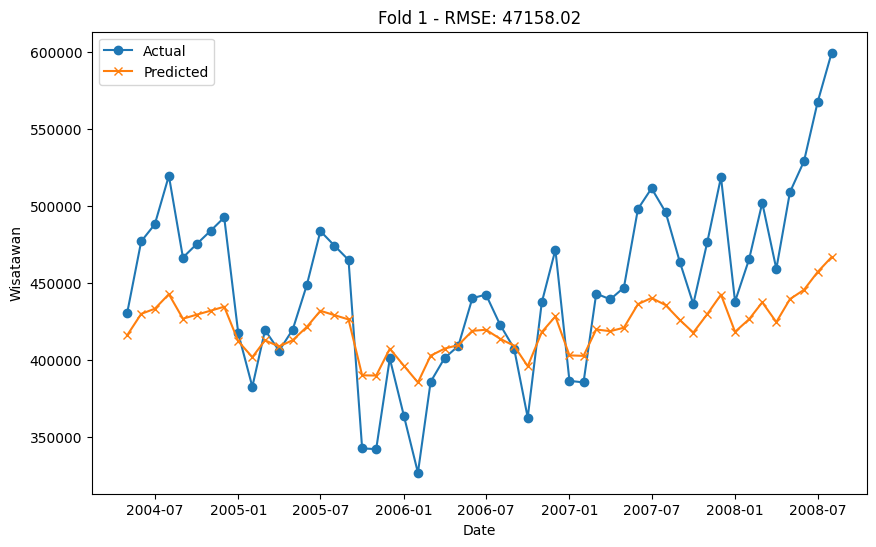

Fold 1 - RMSE: 47158.02


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step


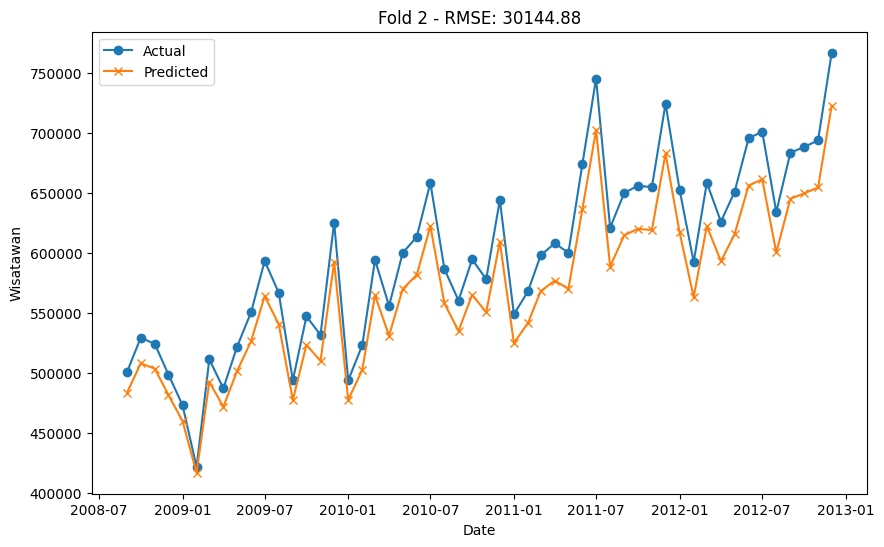

Fold 2 - RMSE: 30144.88


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step


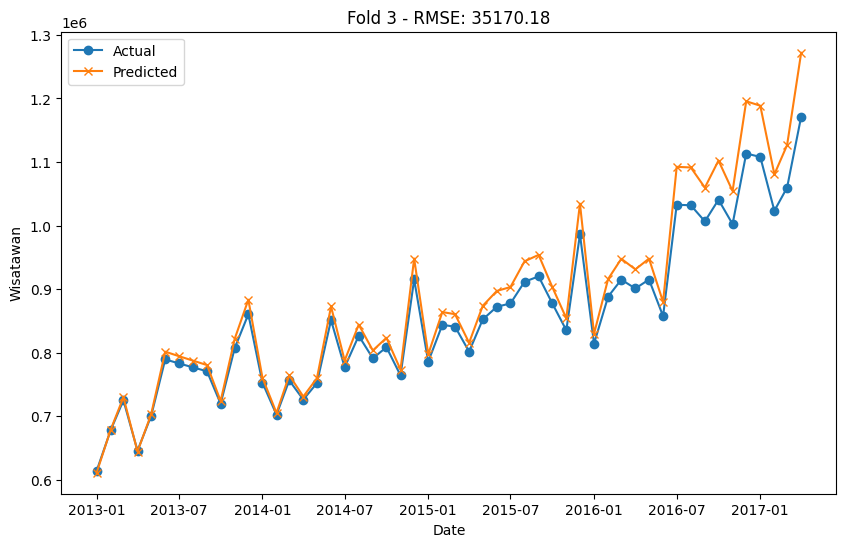

Fold 3 - RMSE: 35170.18


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step


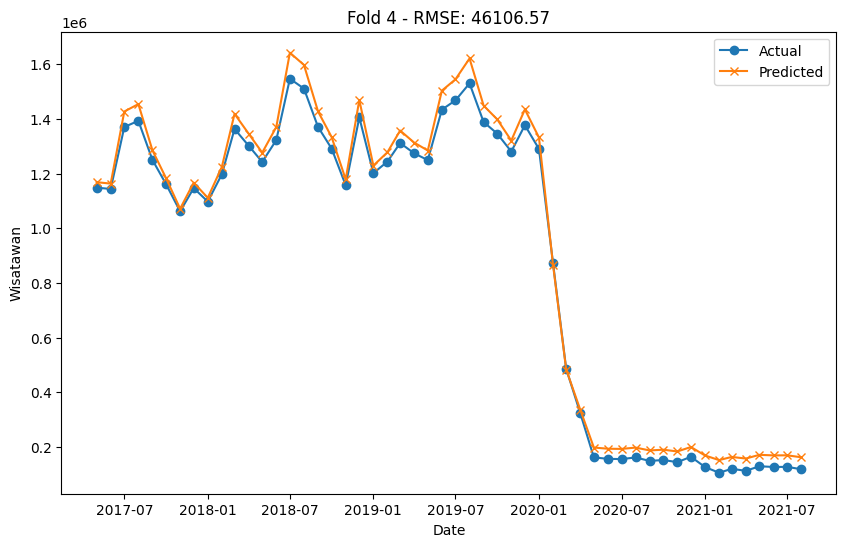

Fold 4 - RMSE: 46106.57


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step


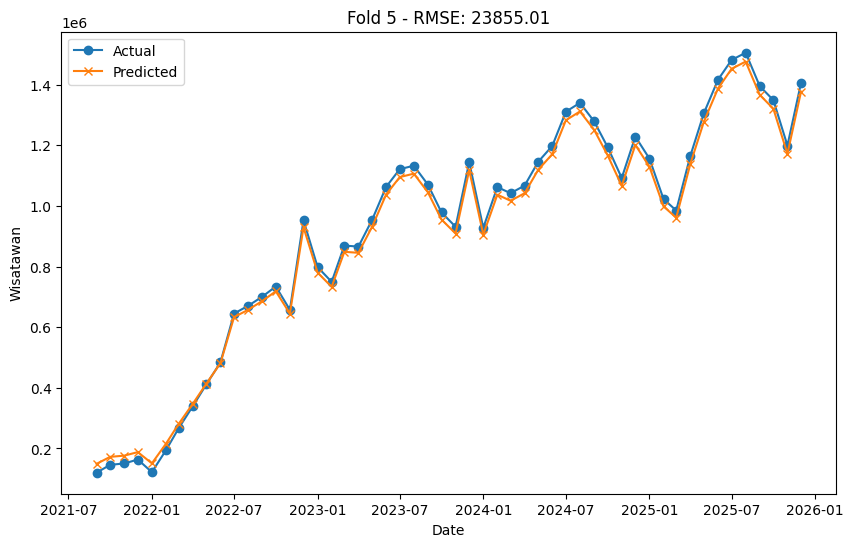

Fold 5 - RMSE: 23855.01

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.001, Batch Size=32
Rata-rata RMSE dari 5-Fold: 36486.93


In [ ]:
#EPOCH: 100, LEARNING RATE: 0,001 dan BATCH SIZE: 32

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 100
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 5

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step


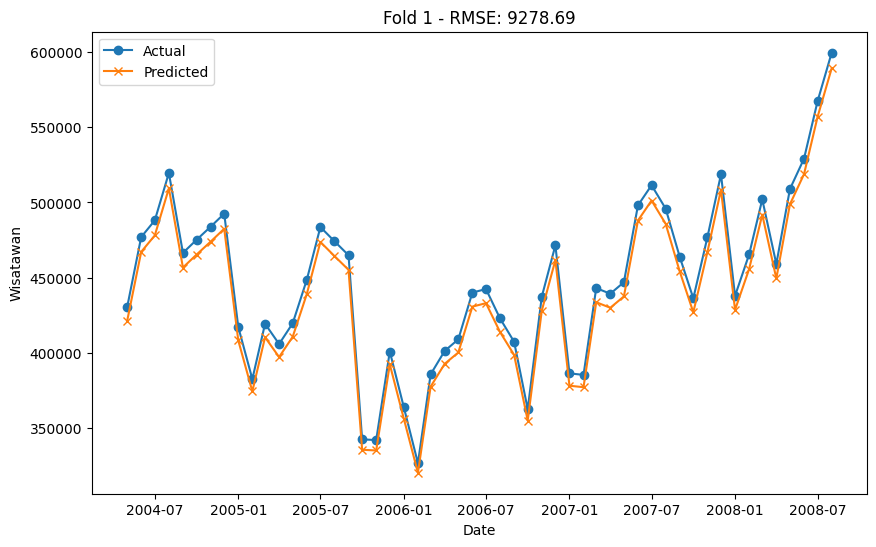

Fold 1 - RMSE: 9278.69


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step


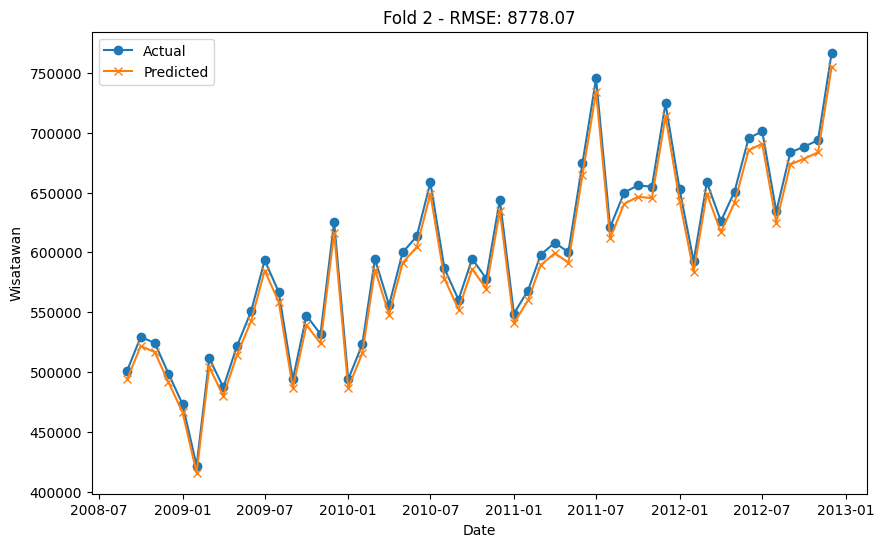

Fold 2 - RMSE: 8778.07


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step


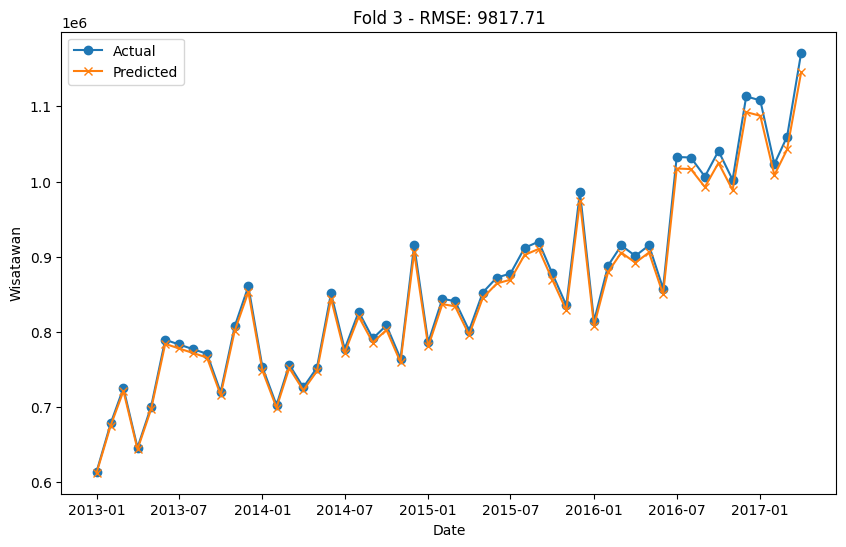

Fold 3 - RMSE: 9817.71


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step


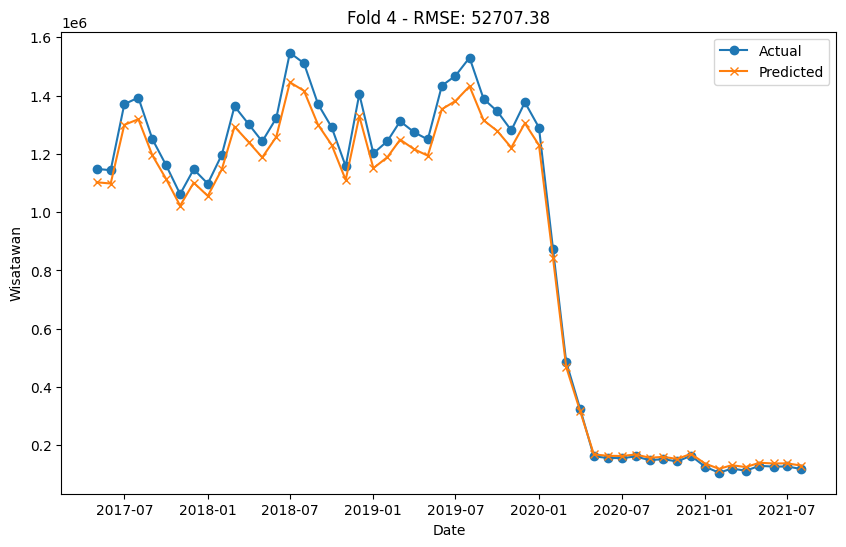

Fold 4 - RMSE: 52707.38


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step


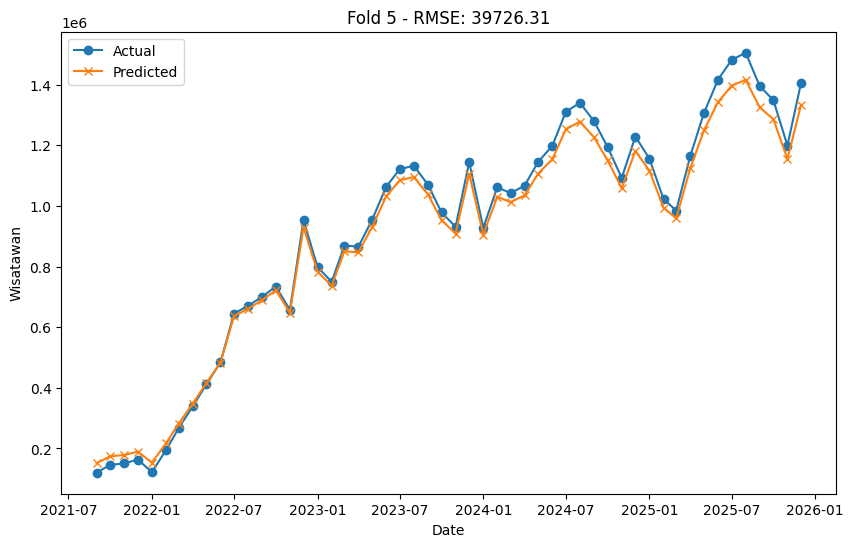

Fold 5 - RMSE: 39726.31

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.01, Batch Size=16
Rata-rata RMSE dari 5-Fold: 24061.64


In [ ]:
#EPOCH: 150, LEARNING RATE: 0,01 dan BATCH SIZE: 16

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.01
batch_size = 16
epochs = 150
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 6

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step


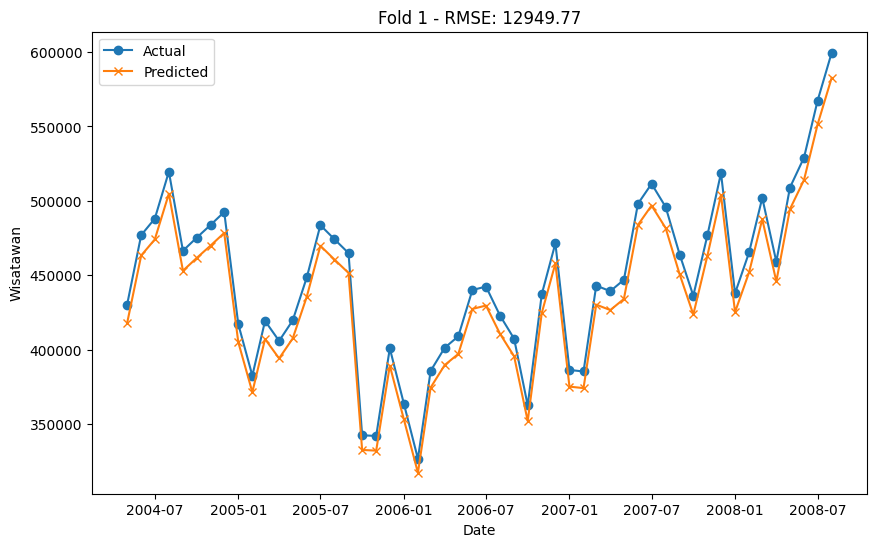

Fold 1 - RMSE: 12949.77


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step


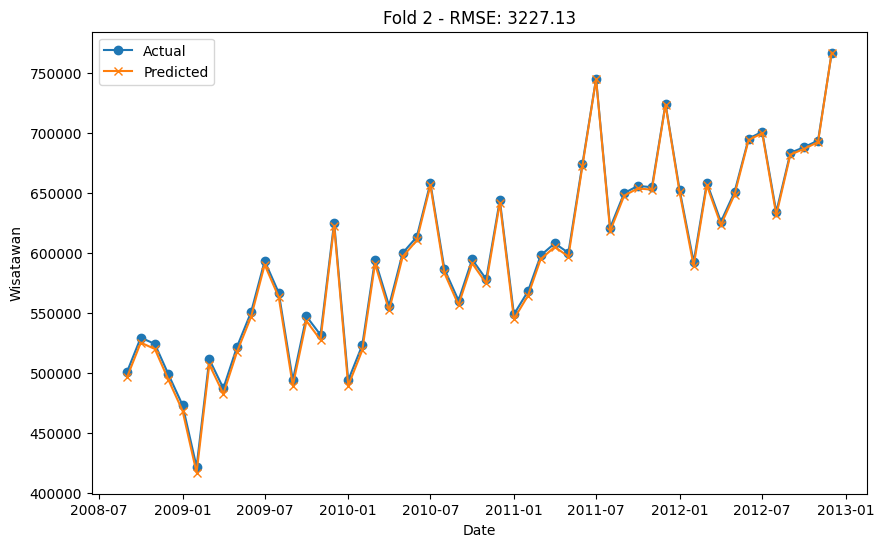

Fold 2 - RMSE: 3227.13


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step


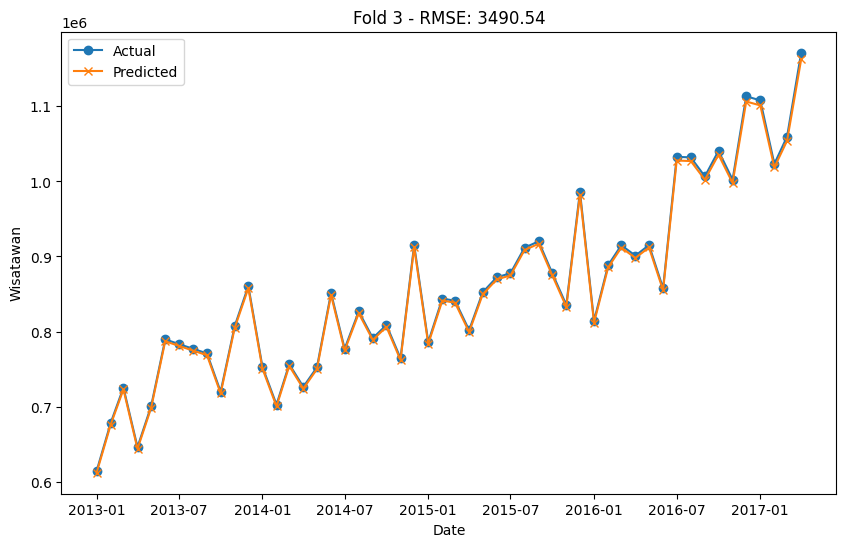

Fold 3 - RMSE: 3490.54


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step


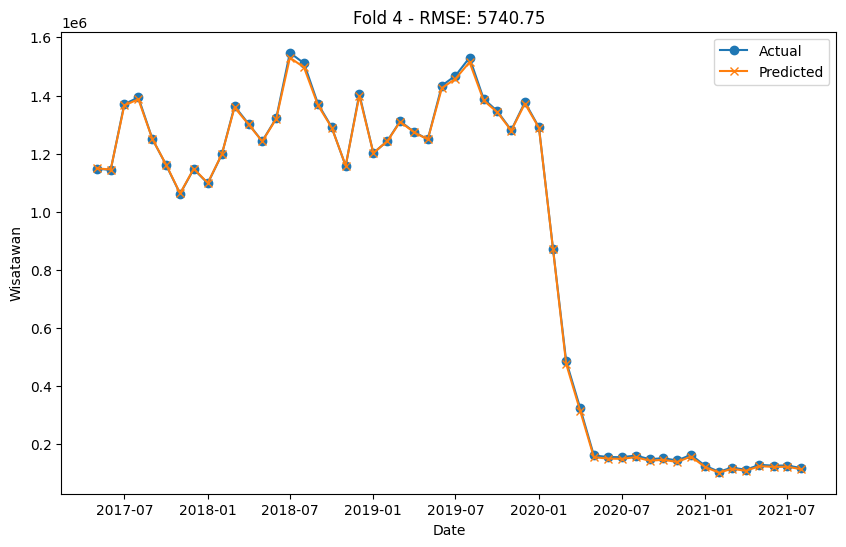

Fold 4 - RMSE: 5740.75


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step


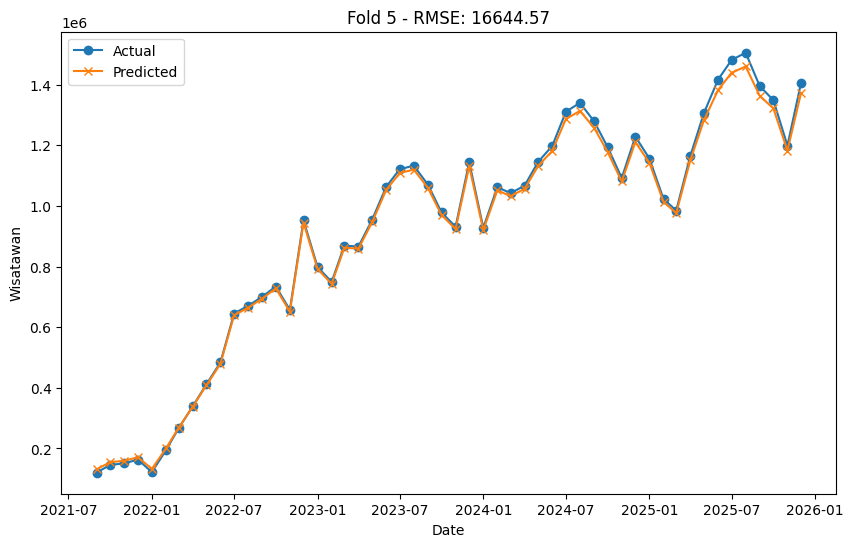

Fold 5 - RMSE: 16644.57

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.01, Batch Size=32
Rata-rata RMSE dari 5-Fold: 8410.55


In [ ]:
#EPOCH: 150, LEARNING RATE: 0,01 dan BATCH SIZE: 32

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.01
batch_size = 32
epochs = 150
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 7

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step


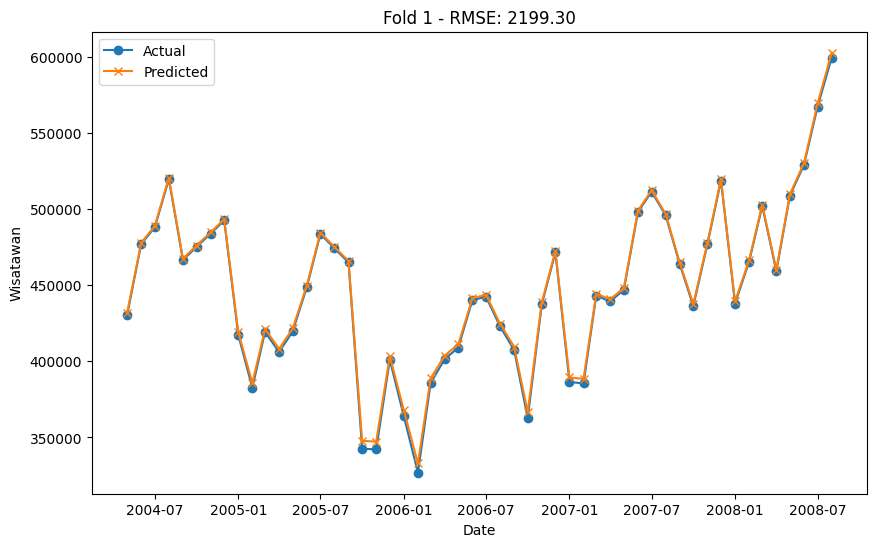

Fold 1 - RMSE: 2199.30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step


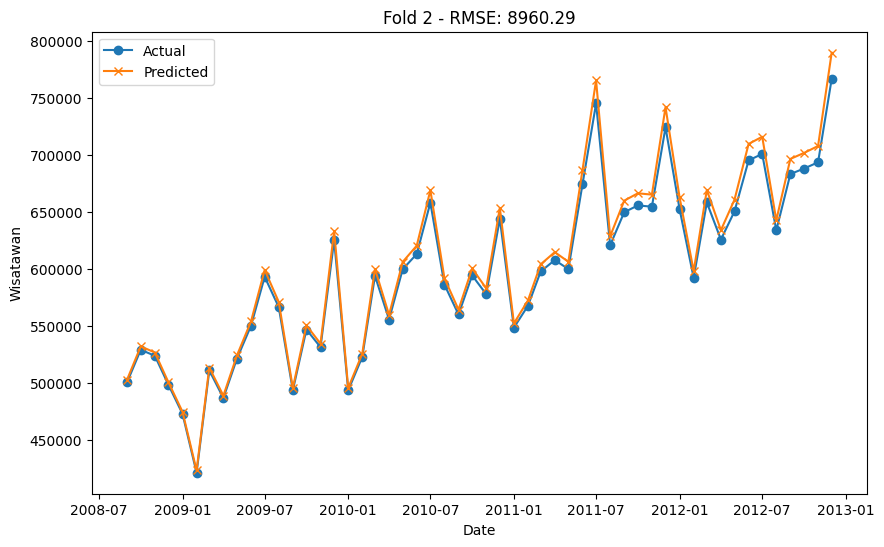

Fold 2 - RMSE: 8960.29


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step


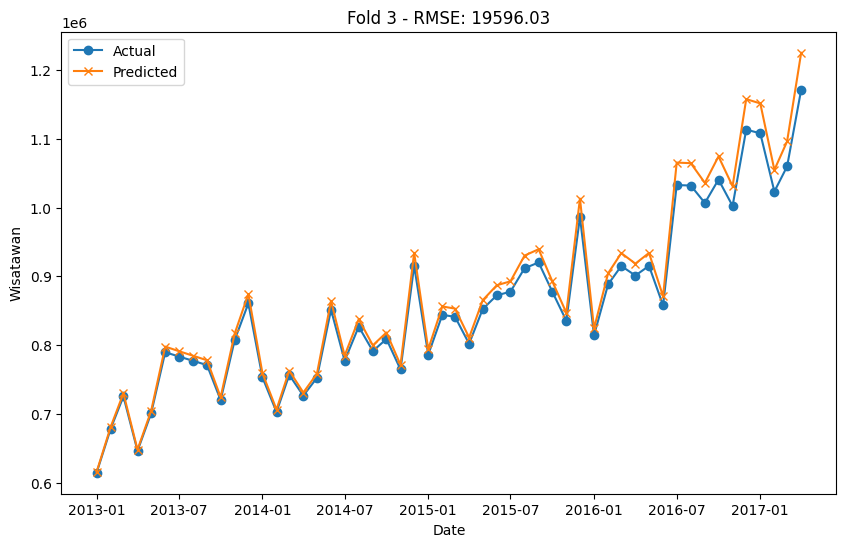

Fold 3 - RMSE: 19596.03


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 303ms/step


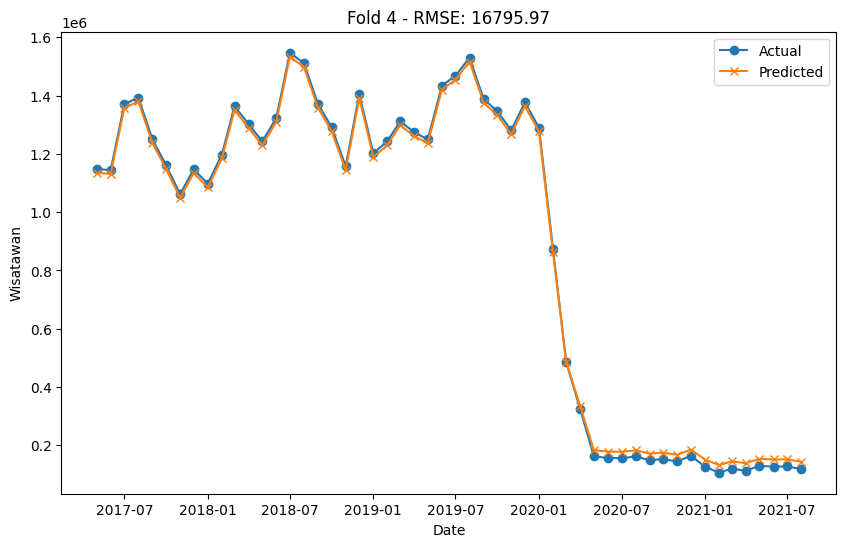

Fold 4 - RMSE: 16795.97


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step


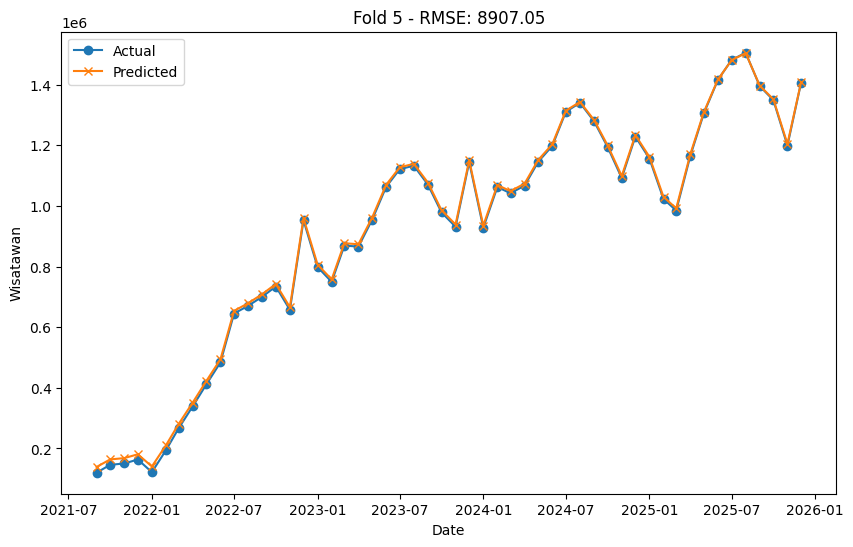

Fold 5 - RMSE: 8907.05

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.001, Batch Size=16
Rata-rata RMSE dari 5-Fold: 11291.73


In [ ]:
#EPOCH: 150, LEARNING RATE: 0,001 dan BATCH SIZE: 16

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.001
batch_size = 16
epochs = 150
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

### Skenario 8

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step


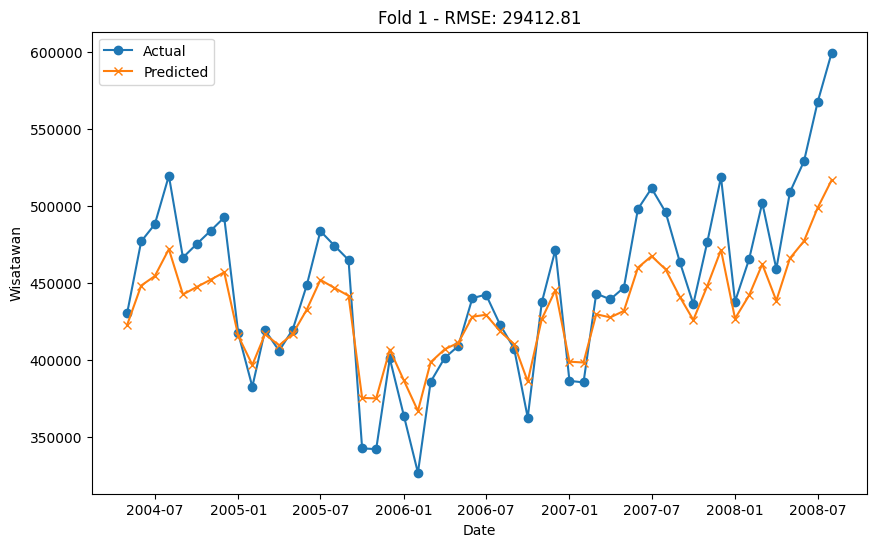

Fold 1 - RMSE: 29412.81


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step


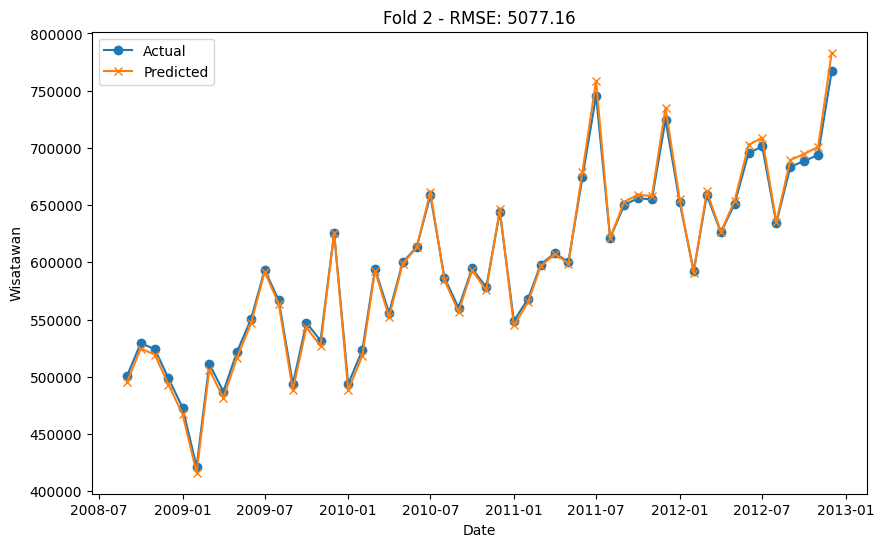

Fold 2 - RMSE: 5077.16


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step


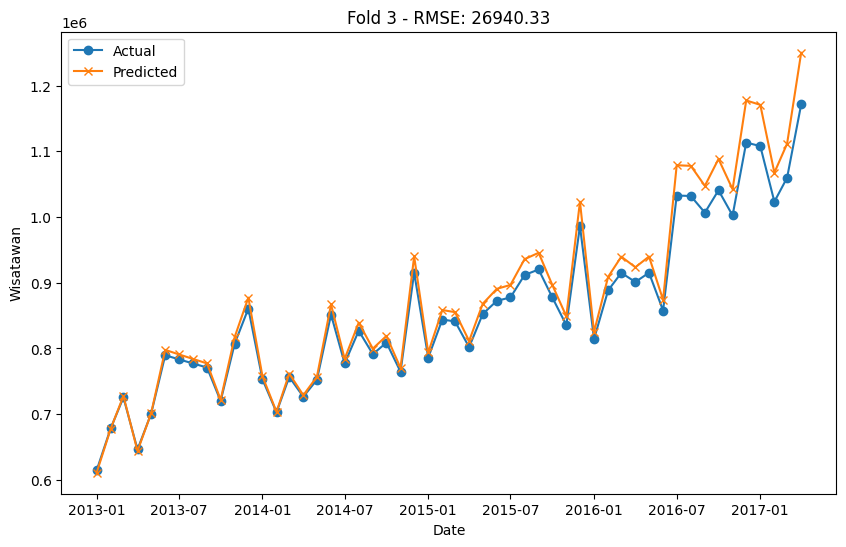

Fold 3 - RMSE: 26940.33


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step


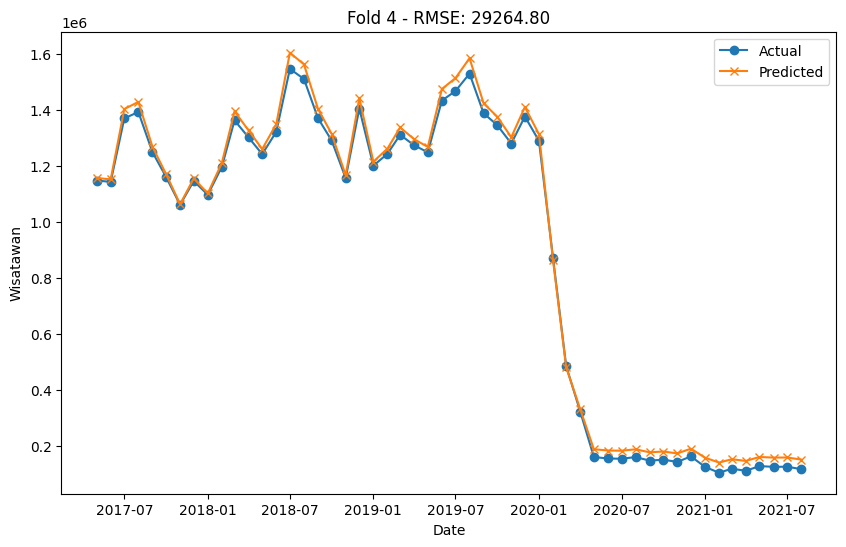

Fold 4 - RMSE: 29264.80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


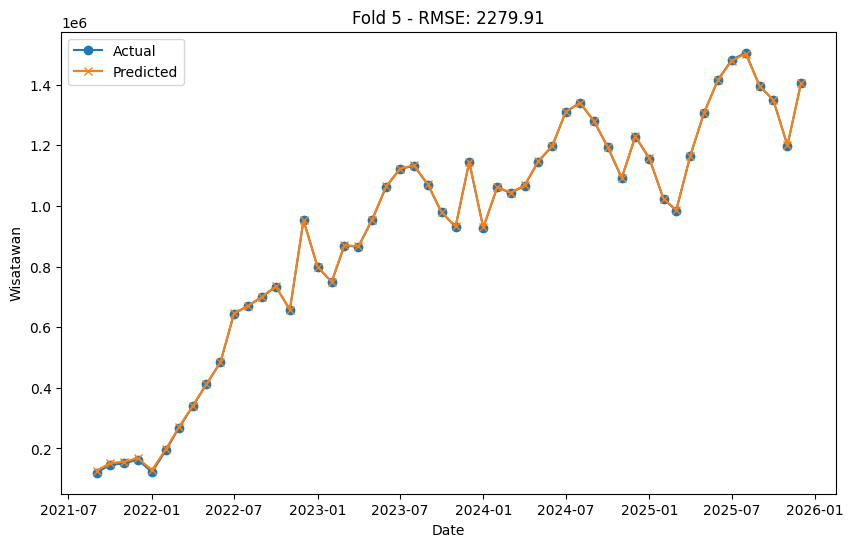

Fold 5 - RMSE: 2279.91

HASIL AKHIR CROSS-VALIDATION (5-Fold)
Parameter: LR=0.001, Batch Size=32
Rata-rata RMSE dari 5-Fold: 18595.00


In [ ]:
#EPOCH: 150, LEARNING RATE: 0,001 dan BATCH SIZE: 32

from sklearn.metrics import mean_squared_error

# Define hyperparameters
learning_rate = 0.001
batch_size = 32
epochs = 150
time_step = 12

# Initialize TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Initialize list to store RMSE values for each fold
rmse_values = []

# Iterate over each fold
for i, (train_index, test_index) in enumerate(tscv.split(data['Wisatawan_normalized'])):
    train_data, test_data = data.iloc[train_index], data.iloc[test_index]

    # Create and train LSTM model
    model = Sequential()
    model.add(LSTM(128, return_sequences=True, input_shape=(time_step, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Inisialisasi optimizer dengan learning rate
    model.compile(loss='mean_squared_error', optimizer=optimizer)
    model.fit(train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              train_data['Wisatawan_normalized'].values.reshape(-1, 1),
              epochs=epochs, batch_size=batch_size, verbose=0)

    # Make predictions
    predictions = model.predict(test_data['Wisatawan_normalized'].values.reshape(-1, 1))
    denormalized_predictions = scaler.inverse_transform(predictions)

    # Calculate RMSE
    actual_values = test_data['Wisatawan'].values
    rmse = np.sqrt(mean_squared_error(actual_values, denormalized_predictions))
    rmse_values.append(rmse)

    # Plot predictions
    plt.figure(figsize=(10, 6))
    plt.plot(test_data['Tanggal'], actual_values, label='Actual', marker='o')
    plt.plot(test_data['Tanggal'], denormalized_predictions, label='Predicted', marker='x')
    plt.title(f"Fold {i+1} - RMSE: {rmse:.2f}")
    plt.xlabel('Date')
    plt.ylabel('Wisatawan')
    plt.legend()
    plt.show()

    print(f"Fold {i+1} - RMSE: {rmse:.2f}")

average_rmse = np.mean(rmse_values)

print("\n" + "="*40)
print("HASIL AKHIR CROSS-VALIDATION (5-Fold)")
print(f"Parameter: LR={learning_rate}, Batch Size={batch_size}")
print(f"Rata-rata RMSE dari 5-Fold: {average_rmse:.2f}")
print("="*40)

# Eksplorasi Data

In [ ]:
data = pd.read_excel('/content/Penanganan.xlsx')
data = data.loc[:, ['Tanggal', 'Wisatawan']]
data = data.iloc[0:].reset_index(drop=True)
print(data)

       Tanggal  Wisatawan
0   2000-01-01     356090
1   2000-02-01     397548
2   2000-03-01     413502
3   2000-04-01     408239
4   2000-05-01     370474
..         ...        ...
307 2025-08-01    1505220
308 2025-09-01    1394910
309 2025-10-01    1348993
310 2025-11-01    1199007
311 2025-12-01    1405860

[312 rows x 2 columns]


Jumlah data latih: 276
Jumlah data uji: 36


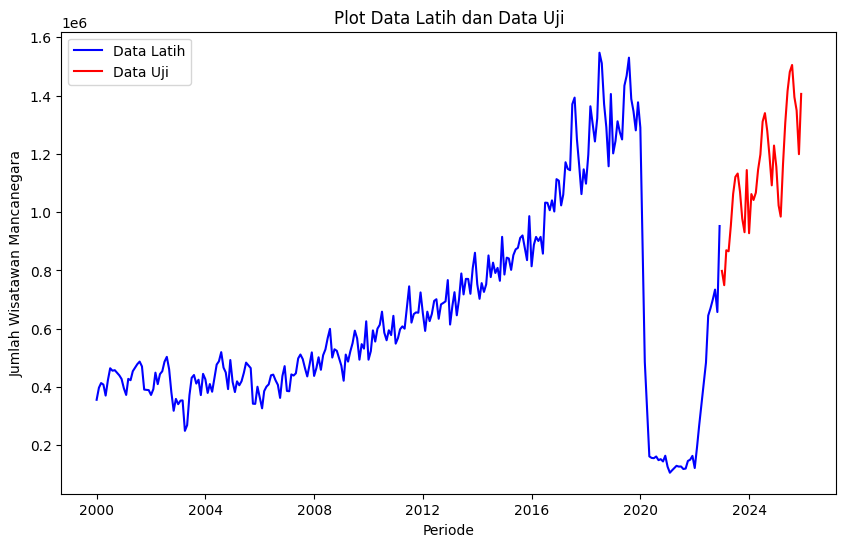

In [ ]:
# Memisahkan data menjadi data latih dan data uji
train_data = data.iloc[:276]
test_data = data.iloc[276:]

# Menampilkan jumlah data dalam setiap bagian untuk memastikan pemisahan yang benar
print("Jumlah data latih:", len(train_data))
print("Jumlah data uji:", len(test_data))
# Membuat plot data latih dan data uji
plt.figure(figsize=(10, 6))
plt.plot(train_data['Tanggal'], train_data['Wisatawan'], label='Data Latih', color='blue')
plt.plot(test_data['Tanggal'], test_data['Wisatawan'], label='Data Uji', color='red')
plt.title('Plot Data Latih dan Data Uji')
plt.xlabel("Periode")
plt.ylabel('Jumlah Wisatawan Mancanegara')
plt.legend()
plt.show()

In [ ]:
time_series_data = data['Wisatawan'].values.reshape(-1, 1)

# Normalisasi data ke rentang 0-1
scaler = MinMaxScaler()
time_series_data = scaler.fit_transform(time_series_data)

# Membagi dataset menjadi data latih dan data uji
train_size = 276
test_size = len(time_series_data) - train_size

train_data = time_series_data[:train_size]
test_data = time_series_data[train_size:]

# Fungsi untuk membuat dataset dengan sekuens deret waktu
def create_sequences(data, seq_length):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i : i + seq_length])
        targets.append(data[i + seq_length])
    return np.array(sequences), np.array(targets)

# Panjang sekuens deret waktu (jumlah waktu sebelum prediksi)
seq_length = 12

# Membuat dataset dengan sekuens deret waktu
X_train, y_train = create_sequences(train_data, seq_length)
combined_test_input = time_series_data[train_size - seq_length:]
X_test, y_test = create_sequences(combined_test_input, seq_length) # Ini tidak akan dipakai untuk prediksi rekursif

# Reshaping data untuk LSTM (jumlah sampel, panjang sekuens, jumlah fitur)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Model LSTM

In [ ]:
# Membangun model LSTM
optimizer = Adam(learning_rate=0.01)
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(seq_length, 1)))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer=optimizer, loss='mse')
# Melatih model
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_data=(X_test, y_test), verbose=10)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 2/150
Epoch 3/150
Epoch 4/150
Epoch 5/150
Epoch 6/150
Epoch 7/150
Epoch 8/150
Epoch 9/150
Epoch 10/150
Epoch 11/150
Epoch 12/150
Epoch 13/150
Epoch 14/150
Epoch 15/150
Epoch 16/150
Epoch 17/150
Epoch 18/150
Epoch 19/150
Epoch 20/150
Epoch 21/150
Epoch 22/150
Epoch 23/150
Epoch 24/150
Epoch 25/150
Epoch 26/150
Epoch 27/150
Epoch 28/150
Epoch 29/150
Epoch 30/150
Epoch 31/150
Epoch 32/150
Epoch 33/150
Epoch 34/150
Epoch 35/150
Epoch 36/150
Epoch 37/150
Epoch 38/150
Epoch 39/150
Epoch 40/150
Epoch 41/150
Epoch 42/150
Epoch 43/150
Epoch 44/150
Epoch 45/150
Epoch 46/150
Epoch 47/150
Epoch 48/150
Epoch 49/150
Epoch 50/150
Epoch 51/150
Epoch 52/150
Epoch 53/150
Epoch 54/150
Epoch 55/150
Epoch 56/150
Epoch 57/150
Epoch 58/150
Epoch 59/150
Epoch 60/150
Epoch 61/150
Epoch 62/150
Epoch 63/150
Epoch 64/150
Epoch 65/150
Epoch 66/150
Epoch 67/150
Epoch 68/150
Epoch 69/150
Epoch 70/150
Epoch 71/150
Epoch 72/150
Epoch 73/150
Epoch 74/150
Epoch 75/150
Epoch 76/150
Epoch 77/150
Epoch 78/150
Epoch 7

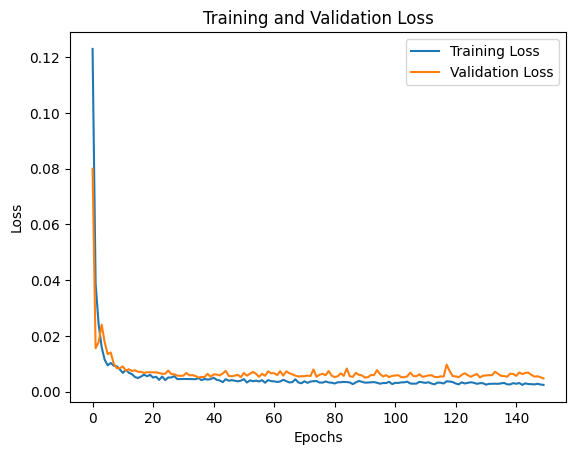

In [ ]:
# Plot loss pada setiap epoch
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step


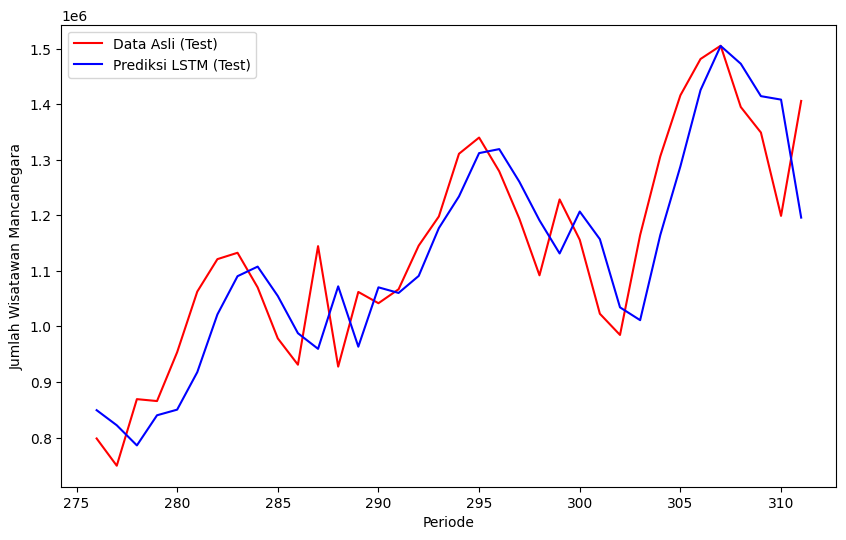

In [ ]:
predicted_test = model.predict(X_test)
predictLSTM_test = scaler.inverse_transform(predicted_test).flatten()

plt.figure(figsize=(10, 6))
plt.plot(data.index[train_size:], data['Wisatawan'].values[train_size:],
         label='Data Asli (Test)', color='red')

plt.plot(data.index[train_size:], predictLSTM_test, label='Prediksi LSTM (Test)', color='blue')

plt.xlabel('Periode')
plt.ylabel('Jumlah Wisatawan Mancanegara')
plt.legend()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


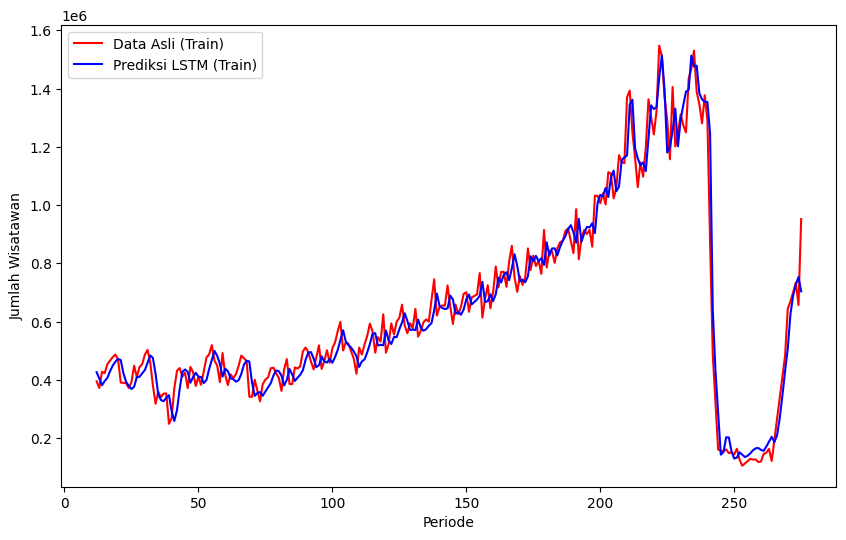

In [ ]:
predicted_train = model.predict(X_train)
predictLSTM_train = scaler.inverse_transform(predicted_train).flatten()

adjusted_train_index = data.index[seq_length:train_size]

plt.figure(figsize=(10, 6))
plt.plot(adjusted_train_index, data['Wisatawan'].values[seq_length:train_size],
         label='Data Asli (Train)', color='red')

plt.plot(adjusted_train_index, predictLSTM_train, label='Prediksi LSTM (Train)', color='blue')

plt.xlabel('Periode')
plt.ylabel('Jumlah Wisatawan')
plt.legend()
plt.show()

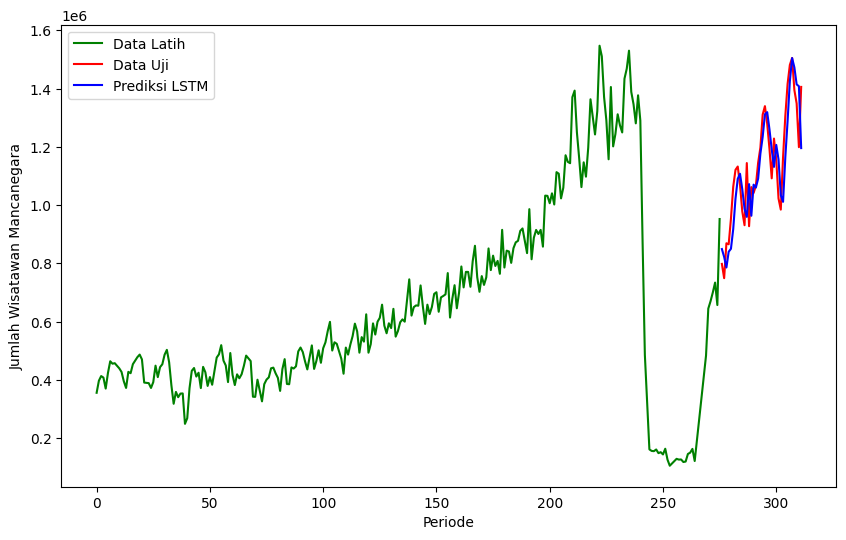

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(data.index[:train_size], data['Wisatawan'].values[:train_size],
    label='Data Latih', color='green')

plt.plot(data.index[train_size:], data['Wisatawan'].values[train_size:],
    label='Data Uji', color='red')

plt.plot(data.index[train_size:], predictLSTM_test,
         label='Prediksi LSTM', color='blue')

plt.xlabel('Periode')
plt.ylabel('Jumlah Wisatawan Mancanegara')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from google.colab import files

# Konversi predictLSTM_train ke pandas DataFrame
df_predictLSTM_train = pd.DataFrame(predictLSTM_train, columns=['Prediksi_LSTM_Train_Penanganan'])

# Simpan DataFrame ke file Excel
df_predictLSTM_train.to_excel("predictLSTM_trainA_akhir_Penanganan.xlsx", index=False)
files.download("predictLSTM_trainA_akhir_Penanganan.xlsx")

# Konversi predictLSTM ke pandas DataFrame
df_predictLSTM_test = pd.DataFrame(predictLSTM_test, columns=['Prediksi_LSTM_Test_Penanganan'])

# Simpan DataFrame ke file Excel
df_predictLSTM_test.to_excel("predictLSTM_testA_akhir_Penanganan.xlsx", index=False)
files.download("predictLSTM_testA_akhir_Penanganan.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
actual_train_values = data['Wisatawan'].values[seq_length:train_size]

# Hitung MAPE dan RMSE Data Training
mape_train = mean_absolute_percentage_error(actual_train_values, predictLSTM_train) * 100
rmse_train = np.sqrt(mean_squared_error(actual_train_values, predictLSTM_train))

# Tampilkan hasil
print("Hasil Evaluasi Data Training (LSTM)")
print(f"MAPE : {mape_train:.2f}%")
print(f"RMSE : {rmse_train:.4f}")

Hasil Evaluasi Data Training (LSTM)
MAPE : 9.48%
RMSE : 64408.9157


In [ ]:
df = pd.read_excel('Penanganan.xlsx')
df = df.loc[:, ['Wisatawan']]

test_df = df.iloc[-36:]

def calculate_mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Hitung MAPE
mape_test = calculate_mape(test_df['Wisatawan'], predictLSTM_test)
rmse_test = np.sqrt(mean_squared_error(test_df['Wisatawan'], predictLSTM_test))

print("Hasil Evaluasi Data Test (LSTM)")
print(f"MAPE : {mape_test:.2f}%")
print(f"RMSE : {rmse_test:.4f}")

Hasil Evaluasi Data Test (LSTM)
MAPE : 7.49%
RMSE : 99232.7172
